### Random Forest

In [10]:

import pandas as pd


import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import confusion_matrix

from sklearn.metrics import confusion_matrix


from sklearn.metrics import confusion_matrix


from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [2]:
file="cleaned_cgga_693_clinical.csv"
df=pd.read_csv(file)
df.head()

,sample_id,tumor_type,tumor_histology,tumor_grade,gender,age,survival_days,survival_status,radio_status,chemo_status,mutation_status,codeletion_status
0,1002,P,anaplastic astrocyma,3,F,43.0,305.0,1.0,1.0,1.0,Wildtype,Non-codel
1,1003,P,oligodendroglioma,2,F,47.0,3817.0,0.0,0.0,1.0,Mutant,Codel
2,1010,P,astrocytoma,2,M,45.0,246.0,1.0,1.0,1.0,Mutant,Non-codel
3,1012,R,oligodendroglioma,2,M,45.0,3679.0,1.0,1.0,1.0,Mutant,Non-codel
4,1014,P,astrocytoma,2,M,42.0,263.0,1.0,0.0,1.0,Wildtype,Non-codel


In [3]:
# drop unnecessary or redundant columns
df = df.drop(columns=['sample_id','survival_days'])

In [4]:
from sklearn.preprocessing import KBinsDiscretizer
discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
df['age_binned'] = discretizer.fit_transform(df[['age']])
# retrieve bin edges to interpret output of dt model later
bin_edges = discretizer.bin_edges_[0]
print(bin_edges)
df=df.drop(columns='age', axis = 1)
df.head()

[11. 33. 40. 46. 55. 76.]


,tumor_type,tumor_histology,tumor_grade,gender,survival_status,radio_status,chemo_status,mutation_status,codeletion_status,age_binned
0,P,anaplastic astrocyma,3,F,1.0,1.0,1.0,Wildtype,Non-codel,2.0
1,P,oligodendroglioma,2,F,0.0,0.0,1.0,Mutant,Codel,3.0
2,P,astrocytoma,2,M,1.0,1.0,1.0,Mutant,Non-codel,2.0
3,R,oligodendroglioma,2,M,1.0,1.0,1.0,Mutant,Non-codel,2.0
4,P,astrocytoma,2,M,1.0,0.0,1.0,Wildtype,Non-codel,2.0


In [5]:
# use one hot encoding to tranform catagorical feautures

from sklearn.preprocessing import OneHotEncoder

#  categorical columns to encode
categorical_cols = ['tumor_type', 'tumor_histology', 'tumor_grade',
                    'gender','radio_status','chemo_status','mutation_status',
                    'codeletion_status','age_binned']  

# fit encoder
encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
X_encoded = encoder.fit_transform(df[categorical_cols])

# get the new column names
encoded_cols = encoder.get_feature_names_out(categorical_cols)

# turn back into a DataFrame
encoded_df = pd.DataFrame(X_encoded, columns=encoded_cols, index=df.index)

# drop original columns and join the new encoded ones
df = df.drop(columns=categorical_cols).join(encoded_df)
df.head()

/Users/julianazweng/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


,survival_status,tumor_type_P,tumor_type_R,tumor_histology_anaplastic astrocyma,tumor_histology_anaplastic oligoastrocytoma,tumor_histology_astrocytoma,tumor_histology_glioblastoma,tumor_histology_oligoastrocytoma,tumor_histology_oligodendroglioma,tumor_grade_2,...,chemo_status_1.0,mutation_status_Mutant,mutation_status_Wildtype,codeletion_status_Codel,codeletion_status_Non-codel,age_binned_0.0,age_binned_1.0,age_binned_2.0,age_binned_3.0,age_binned_4.0
0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


### Step 2: Split data into training and testing

In [6]:
training, testing = train_test_split(df, test_size=.3)
##  Save the Labels and then remove them from the Training and Testing data
training_label = training["survival_status"]
training=training.drop(["survival_status"], axis=1)
testing_label = testing["survival_status"]
testing=testing.drop(["survival_status"], axis=1)
print("Testing:", testing)

Testing:      tumor_type_P  tumor_type_R  tumor_histology_anaplastic astrocyma  \
89            1.0           0.0                                   0.0   
402           0.0           1.0                                   0.0   
177           1.0           0.0                                   0.0   
15            0.0           1.0                                   0.0   
75            1.0           0.0                                   1.0   
..            ...           ...                                   ...   
376           1.0           0.0                                   0.0   
339           1.0           0.0                                   0.0   
169           1.0           0.0                                   0.0   
239           1.0           0.0                                   0.0   
362           1.0           0.0                                   0.0   

     tumor_histology_anaplastic oligoastrocytoma  tumor_histology_astrocytoma  \
89                               

In [7]:
RF = RandomForestClassifier()
RF.fit(training, training_label)
RF_pred=RF.predict(testing)

RF_matrix= confusion_matrix(testing_label, RF_pred)
print("\nThe confusion matrix is:")
print(RF_matrix)



The confusion matrix is:
[[ 45  17]
 [ 19 104]]


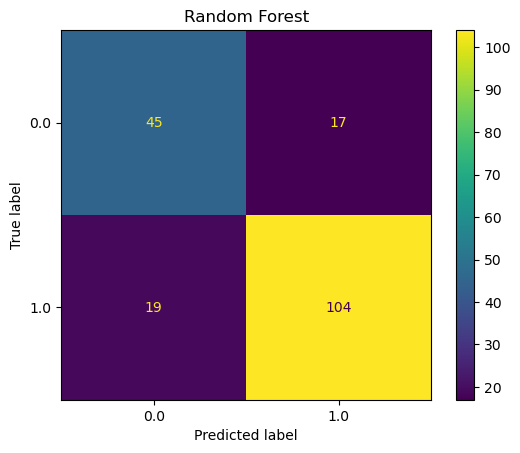

In [8]:
## Pretty confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=RF_matrix,display_labels=RF.classes_)
disp.plot()
plt.title("Random Forest")
plt.show()

In [11]:
# print accuracy

accuracy = accuracy_score(testing_label, RF_pred)
print(f"\nAccuracy: {accuracy:.4f}")


Accuracy: 0.8054


In [12]:
from sklearn.metrics import  classification_report
print("\nClassification Report:")
print(classification_report(testing_label, RF_pred))


Classification Report:
              precision    recall  f1-score   support

         0.0       0.70      0.73      0.71        62
         1.0       0.86      0.85      0.85       123

    accuracy                           0.81       185
   macro avg       0.78      0.79      0.78       185
weighted avg       0.81      0.81      0.81       185

